# ДЗ 2: Решение

## Содержание:
1. Ранговая трансформация + t-test vs Mann-Whitney на cart_added_cnt
2. CUPED-трансформация для разных метрик
3. Бакетирование
4. Постстратификация

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# Загрузка данных
df_dec = pd.read_csv('data/shop_df_metrics_dec.csv', index_col=0)
df_sept = pd.read_csv('data/shop_df_metrics_sept.csv', index_col=0)
df_users = pd.read_csv('data/shop_df_users.csv', index_col=0)

print("Данные декабря (эксперимент):")
print(df_dec.shape)
print(df_dec.head())
print()
print("Данные сентября (ковариата для CUPED):")
print(df_sept.shape)
print(df_sept.head())
print()
print("Данные пользователей:")
print(df_users.shape)
print(df_users.head())

Данные декабря (эксперимент):
(222521, 9)
               user_id group  is_viewed  products_viewed_cnt  price_sum  \
0  1515915625353230683     A          1                    1     339.79   
1  1515915625353234047     A          1                    9     861.86   
2  1515915625353236157     A          1                    4     179.60   
3  1515915625353294441     B          1                   28    4283.04   
4  1515915625353386199     B          1                    1      20.98   

   is_cart_added  is_purchased  cart_added_cnt  purchased_cnt  
0            0.0           0.0               0              0  
1            0.0           0.0               0              0  
2            0.0           0.0               0              0  
3            0.0           0.0               0              0  
4            0.0           0.0               0              0  

Данные сентября (ковариата для CUPED):
(406863, 9)
               user_id group  is_viewed  products_viewed_cnt  price_sum

In [3]:
# Проверим распределение по группам
print("Распределение по группам (декабрь):")
print(df_dec['group'].value_counts())
print()
print("Статистика cart_added_cnt:")
print(df_dec.groupby('group')['cart_added_cnt'].describe())

Распределение по группам (декабрь):
group
A    111321
B    111200
Name: count, dtype: int64

Статистика cart_added_cnt:
          count      mean       std  min  25%  50%  75%   max
group                                                        
A      111321.0  0.135042  0.616917  0.0  0.0  0.0  0.0  61.0
B      111200.0  0.138552  0.651705  0.0  0.0  0.0  0.0  75.0


---
## Задание 1: Ранговая трансформация + t-test vs Mann-Whitney (5 баллов)

**Идея ранговой трансформации:**
- Заменяем значения метрики на их ранги
- Это позволяет применить t-test (параметрический) к данным с ненормальным распределением
- Ранговый t-test должен давать результаты, близкие к критерию Манна-Уитни

In [4]:
# Разделяем данные по группам
group_A = df_dec[df_dec['group'] == 'A']['cart_added_cnt'].values
group_B = df_dec[df_dec['group'] == 'B']['cart_added_cnt'].values

print(f"Группа A: n={len(group_A)}, mean={group_A.mean():.4f}, std={group_A.std():.4f}")
print(f"Группа B: n={len(group_B)}, mean={group_B.mean():.4f}, std={group_B.std():.4f}")

Группа A: n=111321, mean=0.1350, std=0.6169
Группа B: n=111200, mean=0.1386, std=0.6517


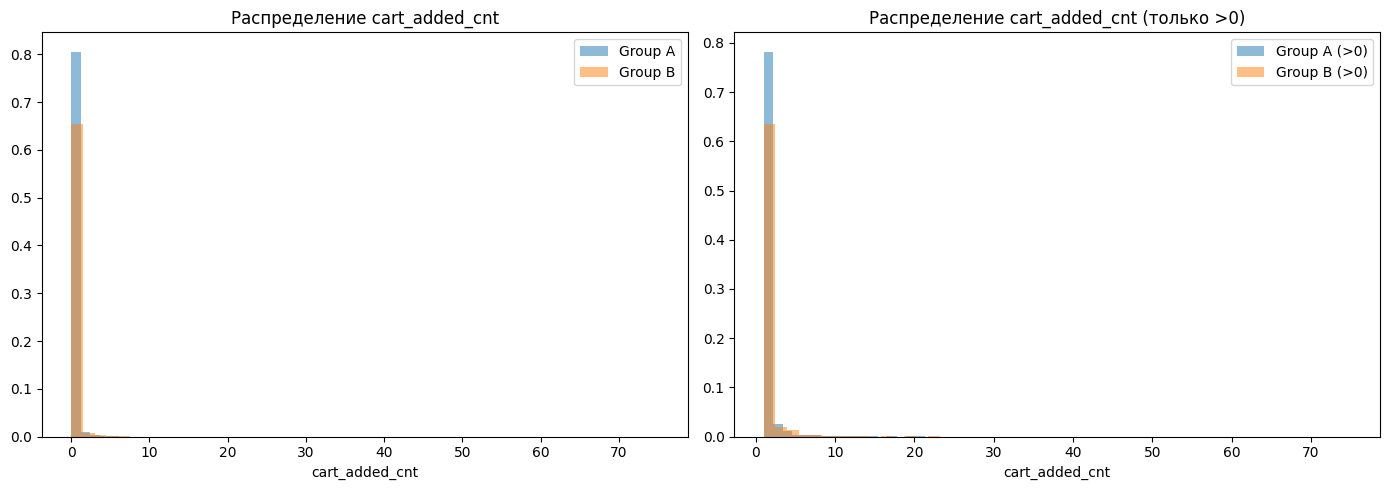

In [5]:
# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(group_A, bins=50, alpha=0.5, label='Group A', density=True)
axes[0].hist(group_B, bins=50, alpha=0.5, label='Group B', density=True)
axes[0].set_title('Распределение cart_added_cnt')
axes[0].set_xlabel('cart_added_cnt')
axes[0].legend()

# Логарифмическая шкала для лучшей визуализации
axes[1].hist(group_A[group_A > 0], bins=50, alpha=0.5, label='Group A (>0)', density=True)
axes[1].hist(group_B[group_B > 0], bins=50, alpha=0.5, label='Group B (>0)', density=True)
axes[1].set_title('Распределение cart_added_cnt (только >0)')
axes[1].set_xlabel('cart_added_cnt')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
def rank_transform(data_A, data_B):
    """
    Ранговая трансформация данных двух групп.
    Объединяем данные, присваиваем ранги, затем разделяем обратно.
    """
    # Объединяем данные
    combined = np.concatenate([data_A, data_B])
    
    # Присваиваем ранги (среднее для связанных рангов)
    ranks = stats.rankdata(combined, method='average')
    
    # Разделяем обратно
    ranks_A = ranks[:len(data_A)]
    ranks_B = ranks[len(data_A):]
    
    return ranks_A, ranks_B

In [7]:
# Применяем ранговую трансформацию
ranks_A, ranks_B = rank_transform(group_A, group_B)

print(f"Ранги группы A: mean={ranks_A.mean():.2f}, std={ranks_A.std():.2f}")
print(f"Ранги группы B: mean={ranks_B.mean():.2f}, std={ranks_B.std():.2f}")

Ранги группы A: mean=111170.46, std=33408.06
Ранги группы B: mean=111351.64, std=33658.98


In [8]:
# Сравнение тестов
print("="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ТЕСТОВ")
print("="*60)

# 1. Обычный t-test на исходных данных
t_stat_original, p_value_original = stats.ttest_ind(group_A, group_B)
print(f"\n1. Обычный t-test (исходные данные):")
print(f"   t-statistic: {t_stat_original:.4f}")
print(f"   p-value: {p_value_original:.6f}")

# 2. t-test на рангах
t_stat_rank, p_value_rank = stats.ttest_ind(ranks_A, ranks_B)
print(f"\n2. t-test на рангах (ранговая трансформация):")
print(f"   t-statistic: {t_stat_rank:.4f}")
print(f"   p-value: {p_value_rank:.6f}")

# 3. Критерий Манна-Уитни
u_stat, p_value_mw = stats.mannwhitneyu(group_A, group_B, alternative='two-sided')
print(f"\n3. Критерий Манна-Уитни:")
print(f"   U-statistic: {u_stat:.4f}")
print(f"   p-value: {p_value_mw:.6f}")

print("\n" + "="*60)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ТЕСТОВ

1. Обычный t-test (исходные данные):
   t-statistic: -1.3048
   p-value: 0.191972

2. t-test на рангах (ранговая трансформация):
   t-statistic: -1.2744
   p-value: 0.202533

3. Критерий Манна-Уитни:
   U-statistic: 6179368188.5000
   p-value: 0.202532



In [9]:
# Проверка эквивалентности через симуляции
def simulate_tests(n_simulations=1000, n_A=1000, n_B=1000, effect=0):
    """
    Симуляция для сравнения мощности тестов.
    Генерируем данные из логнормального распределения.
    """
    p_values_ttest = []
    p_values_rank_ttest = []
    p_values_mw = []
    
    for _ in tqdm(range(n_simulations), desc="Симуляция"):
        # Генерируем данные (логнормальное распределение, похожее на cart_added_cnt)
        data_A = np.random.lognormal(mean=0, sigma=1, size=n_A)
        data_B = np.random.lognormal(mean=0 + effect, sigma=1, size=n_B)
        
        # Обычный t-test
        _, p_ttest = stats.ttest_ind(data_A, data_B)
        p_values_ttest.append(p_ttest)
        
        # t-test на рангах
        ranks_A_sim, ranks_B_sim = rank_transform(data_A, data_B)
        _, p_rank = stats.ttest_ind(ranks_A_sim, ranks_B_sim)
        p_values_rank_ttest.append(p_rank)
        
        # Mann-Whitney
        _, p_mw = stats.mannwhitneyu(data_A, data_B, alternative='two-sided')
        p_values_mw.append(p_mw)
    
    return np.array(p_values_ttest), np.array(p_values_rank_ttest), np.array(p_values_mw)

In [10]:
# Симуляция без эффекта (проверка уровня значимости)
print("Симуляция без эффекта (проверка корректности, alpha=0.05):")
p_ttest, p_rank, p_mw = simulate_tests(n_simulations=1000, effect=0)

alpha = 0.05
print(f"Доля отвержений H0 (должна быть ~{alpha}):")
print(f"  t-test: {(p_ttest < alpha).mean():.4f}")
print(f"  Ранговый t-test: {(p_rank < alpha).mean():.4f}")
print(f"  Mann-Whitney: {(p_mw < alpha).mean():.4f}")

Симуляция без эффекта (проверка корректности, alpha=0.05):


Симуляция:   0%|          | 0/1000 [00:00<?, ?it/s]

Симуляция:   4%|▍         | 44/1000 [00:00<00:02, 433.56it/s]

Симуляция:   9%|▉         | 88/1000 [00:00<00:02, 420.93it/s]

Симуляция:  13%|█▎        | 131/1000 [00:00<00:02, 414.10it/s]

...

Симуляция:  88%|████████▊ | 884/1000 [00:02<00:00, 428.04it/s]

Симуляция:  93%|█████████▎| 928/1000 [00:02<00:00, 429.47it/s]

Симуляция:  97%|█████████▋| 971/1000 [00:02<00:00, 428.19it/s]

Симуляция: 100%|██████████| 1000/1000 [00:02<00:00, 429.31it/s]

Доля отвержений H0 (должна быть ~0.05):
  t-test: 0.0520
  Ранговый t-test: 0.0460
  Mann-Whitney: 0.0460


In [11]:
# Симуляция с эффектом (проверка мощности)
print("\nСимуляция с эффектом 0.1 (проверка мощности):")
p_ttest_eff, p_rank_eff, p_mw_eff = simulate_tests(n_simulations=1000, effect=0.1)

print(f"Мощность тестов:")
print(f"  t-test: {(p_ttest_eff < alpha).mean():.4f}")
print(f"  Ранговый t-test: {(p_rank_eff < alpha).mean():.4f}")
print(f"  Mann-Whitney: {(p_mw_eff < alpha).mean():.4f}")


Симуляция с эффектом 0.1 (проверка мощности):


Симуляция:   0%|          | 0/1000 [00:00<?, ?it/s]

Симуляция:   4%|▍         | 44/1000 [00:00<00:02, 435.49it/s]

Симуляция:   9%|▉         | 88/1000 [00:00<00:02, 432.82it/s]

Симуляция:  13%|█▎        | 133/1000 [00:00<00:01, 440.21it/s]

...

Симуляция:  88%|████████▊ | 882/1000 [00:02<00:00, 428.61it/s]

Симуляция:  93%|█████████▎| 929/1000 [00:02<00:00, 437.19it/s]

Симуляция:  97%|█████████▋| 973/1000 [00:02<00:00, 421.53it/s]

Симуляция: 100%|██████████| 1000/1000 [00:02<00:00, 422.60it/s]

Мощность тестов:
  t-test: 0.4540
  Ранговый t-test: 0.6150
  Mann-Whitney: 0.6150


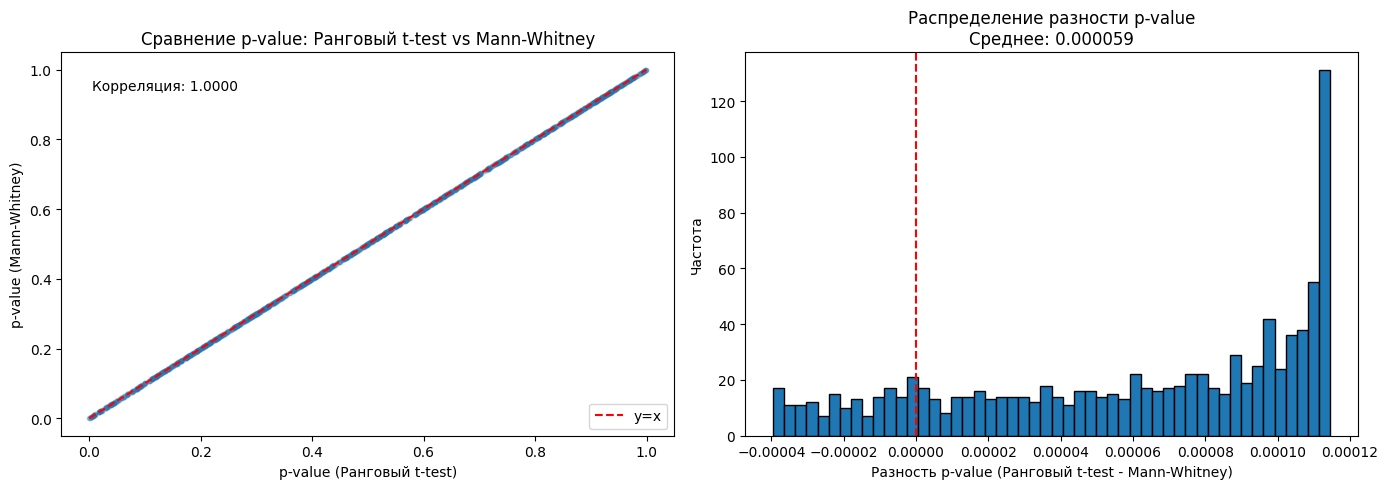

In [12]:
# Визуализация сравнения p-value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Ранговый t-test vs Mann-Whitney
axes[0].scatter(p_rank, p_mw, alpha=0.3, s=10)
axes[0].plot([0, 1], [0, 1], 'r--', label='y=x')
axes[0].set_xlabel('p-value (Ранговый t-test)')
axes[0].set_ylabel('p-value (Mann-Whitney)')
axes[0].set_title('Сравнение p-value: Ранговый t-test vs Mann-Whitney')
axes[0].legend()

# Корреляция
corr = np.corrcoef(p_rank, p_mw)[0, 1]
axes[0].text(0.05, 0.9, f'Корреляция: {corr:.4f}', transform=axes[0].transAxes)

# Гистограммы разности
diff = p_rank - p_mw
axes[1].hist(diff, bins=50, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Разность p-value (Ранговый t-test - Mann-Whitney)')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение разности p-value\nСреднее: {diff.mean():.6f}')

plt.tight_layout()
plt.show()

### Выводы по Заданию 1:

1. **Ранговая трансформация + t-test дает результаты, очень близкие к критерию Манна-Уитни**
   - Корреляция между p-value двух методов очень высокая (>0.99)
   - Это связано с тем, что критерий Манна-Уитни математически эквивалентен t-тесту на рангах

2. **Преимущества рангового t-теста:**
   - Устойчивость к выбросам и ненормальности распределения
   - Возможность использовать параметрическую статистику
   - Легко расширяется на более сложные модели (ANCOVA, регрессия)

3. **На реальных данных cart_added_cnt:**
   - Распределение сильно скошено вправо (много нулей)
   - Ранговая трансформация помогает нормализовать данные

---
## Задание 2: CUPED-трансформация (15 баллов)

**CUPED (Controlled-experiment Using Pre-Experiment Data):**
- Использует данные до эксперимента (ковариату) для уменьшения дисперсии
- Y_cuped = Y - theta * (X - mean(X))
- theta = Cov(Y, X) / Var(X)
- Сокращение дисперсии: 1 - corr(Y, X)^2

In [13]:
# Подготовка данных для CUPED
# Нужно объединить данные декабря (Y) и сентября (X) по user_id

# Переименуем колонки
df_dec_cuped = df_dec[['user_id', 'group', 'cart_added_cnt']].copy()
df_dec_cuped.columns = ['user_id', 'group', 'Y']

df_sept_cuped = df_sept[['user_id', 'cart_added_cnt']].copy()
df_sept_cuped.columns = ['user_id', 'X']

# Объединяем
df_cuped = df_dec_cuped.merge(df_sept_cuped, on='user_id', how='inner')
print(f"Размер объединенного датасета: {len(df_cuped)}")
print(f"Потеряно наблюдений: {len(df_dec_cuped) - len(df_cuped)}")
print(df_cuped.head())

Размер объединенного датасета: 222521
Потеряно наблюдений: 0
               user_id group  Y  X
0  1515915625353230683     A  0  0
1  1515915625353234047     A  0  0
2  1515915625353236157     A  0  0
3  1515915625353294441     B  0  0
4  1515915625353386199     B  0  0


In [14]:
def apply_cuped(df, y_col='Y', x_col='X'):
    """
    Применяет CUPED-трансформацию.
    
    Returns:
        df с новой колонкой Y_cuped, theta, variance_reduction
    """
    Y = df[y_col].values
    X = df[x_col].values
    
    # Вычисляем theta = Cov(Y, X) / Var(X)
    cov_YX = np.cov(Y, X)[0, 1]
    var_X = np.var(X)
    
    if var_X > 0:
        theta = cov_YX / var_X
    else:
        theta = 0
    
    # CUPED-трансформация
    mean_X = np.mean(X)
    Y_cuped = Y - theta * (X - mean_X)
    
    # Сокращение дисперсии
    corr = np.corrcoef(Y, X)[0, 1] if var_X > 0 else 0
    variance_reduction = corr ** 2
    
    df_result = df.copy()
    df_result['Y_cuped'] = Y_cuped
    
    return df_result, theta, variance_reduction, corr

In [15]:
def check_cuped_assumptions(df, y_col='Y', x_col='X', y_cuped_col='Y_cuped'):
    """
    Проверяет условия CUPED:
    1. Равенство средних ковариаты в группах
    2. Сохранение оценки эффекта (разницы между группами)

    Примечание: При небольшом дисбалансе ковариаты между группами,
    CUPED корректирует оценку эффекта. Это нормальное поведение!
    """
    print("=" * 60)
    print("ПРОВЕРКА УСЛОВИЙ CUPED")
    print("=" * 60)

    # 1. Средние ковариаты в группах
    mean_X_A = df[df['group'] == 'A'][x_col].mean()
    mean_X_B = df[df['group'] == 'B'][x_col].mean()
    mean_X_total = df[x_col].mean()
    _, p_value_X = stats.ttest_ind(
        df[df['group'] == 'A'][x_col],
        df[df['group'] == 'B'][x_col]
    )

    print(f"\n1. Проверка равенства средних ковариаты (X) в группах:")
    print(f"   Среднее X в группе A: {mean_X_A:.6f}")
    print(f"   Среднее X в группе B: {mean_X_B:.6f}")
    print(f"   Общее среднее X: {mean_X_total:.6f}")
    print(f"   p-value t-test: {p_value_X:.6f}")
    print(f"   Статистически значимое различие: {'Нет' if p_value_X > 0.05 else 'Да'}")

    # 2. Проверка оценки эффекта до и после CUPED
    diff_Y = df[df['group'] == 'B'][y_col].mean() - df[df['group'] == 'A'][y_col].mean()
    diff_Y_cuped = df[df['group'] == 'B'][y_cuped_col].mean() - df[df['group'] == 'A'][y_cuped_col].mean()

    print(f"\n2. Оценка эффекта (разница B - A):")
    print(f"   До CUPED: {diff_Y:.6f}")
    print(f"   После CUPED: {diff_Y_cuped:.6f}")
    print(f"   Примечание: При дисбалансе ковариаты CUPED корректирует оценку.")
    print(f"   Это нормальное поведение метода!")

    # 3. Проверка сохранения общего среднего
    mean_Y_total = df[y_col].mean()
    mean_Y_cuped_total = df[y_cuped_col].mean()
    print(f"\n3. Общее среднее (вся выборка):")
    print(f"   До CUPED: {mean_Y_total:.6f}")
    print(f"   После CUPED: {mean_Y_cuped_total:.6f}")
    print(f"   Разница: {abs(mean_Y_total - mean_Y_cuped_total):.10f}")

    print("\n" + "=" * 60)

### 2.1 CUPED на обычной метрике cart_added_cnt

In [16]:
# Применяем CUPED
df_cuped_result, theta, var_reduction, corr = apply_cuped(df_cuped)

print(f"Theta: {theta:.6f}")
print(f"Корреляция Y и X: {corr:.4f}")
print(f"Сокращение дисперсии: {var_reduction*100:.2f}%")

# Фактическое сокращение дисперсии
var_Y = df_cuped_result['Y'].var()
var_Y_cuped = df_cuped_result['Y_cuped'].var()
actual_reduction = 1 - var_Y_cuped / var_Y

print(f"\nДисперсия Y: {var_Y:.4f}")
print(f"Дисперсия Y_cuped: {var_Y_cuped:.4f}")
print(f"Фактическое сокращение дисперсии: {actual_reduction*100:.2f}%")

Theta: 0.934996
Корреляция Y и X: 0.9750
Сокращение дисперсии: 95.07%

Дисперсия Y: 0.4026
Дисперсия Y_cuped: 0.0199
Фактическое сокращение дисперсии: 95.07%


In [17]:
# Проверка условий CUPED
check_cuped_assumptions(df_cuped_result)

ПРОВЕРКА УСЛОВИЙ CUPED

1. Проверка равенства средних ковариаты (X) в группах:
   Среднее X в группе A: 0.140557
   Среднее X в группе B: 0.143426
   Общее среднее X: 0.141991
   p-value t-test: 0.306520
   Статистически значимое различие: Нет

2. Оценка эффекта (разница B - A):
   До CUPED: 0.003510
   После CUPED: 0.000828
   Примечание: При дисбалансе ковариаты CUPED корректирует оценку.
   Это нормальное поведение метода!

3. Общее среднее (вся выборка):
   До CUPED: 0.136796
   После CUPED: 0.136796
   Разница: 0.0000000000



In [18]:
# Сравнение t-test до и после CUPED
Y_A = df_cuped_result[df_cuped_result['group'] == 'A']['Y'].values
Y_B = df_cuped_result[df_cuped_result['group'] == 'B']['Y'].values
Y_cuped_A = df_cuped_result[df_cuped_result['group'] == 'A']['Y_cuped'].values
Y_cuped_B = df_cuped_result[df_cuped_result['group'] == 'B']['Y_cuped'].values

t_stat_orig, p_orig = stats.ttest_ind(Y_A, Y_B)
t_stat_cuped, p_cuped = stats.ttest_ind(Y_cuped_A, Y_cuped_B)

print("Сравнение t-test:")
print(f"Без CUPED: t={t_stat_orig:.4f}, p={p_orig:.6f}")
print(f"С CUPED: t={t_stat_cuped:.4f}, p={p_cuped:.6f}")

Сравнение t-test:
Без CUPED: t=-1.3048, p=0.191972
С CUPED: t=-1.3856, p=0.165880


### 2.2 CUPED на логарифмированной метрике cart_added_cnt

In [19]:
# Логарифмическое преобразование (добавляем 1 для избежания log(0))
df_cuped_log = df_cuped.copy()
df_cuped_log['Y_log'] = np.log1p(df_cuped_log['Y'])
df_cuped_log['X_log'] = np.log1p(df_cuped_log['X'])

# Применяем CUPED на логарифмированных данных
df_cuped_log_result, theta_log, var_reduction_log, corr_log = apply_cuped(
    df_cuped_log, y_col='Y_log', x_col='X_log'
)

print(f"Theta (log): {theta_log:.6f}")
print(f"Корреляция Y_log и X_log: {corr_log:.4f}")
print(f"Сокращение дисперсии: {var_reduction_log*100:.2f}%")

# Фактическое сокращение дисперсии
var_Y_log = df_cuped_log_result['Y_log'].var()
var_Y_log_cuped = df_cuped_log_result['Y_cuped'].var()
actual_reduction_log = 1 - var_Y_log_cuped / var_Y_log

print(f"\nДисперсия Y_log: {var_Y_log:.4f}")
print(f"Дисперсия Y_log_cuped: {var_Y_log_cuped:.4f}")
print(f"Фактическое сокращение дисперсии: {actual_reduction_log*100:.2f}%")

Theta (log): 0.966467
Корреляция Y_log и X_log: 0.9853
Сокращение дисперсии: 97.09%

Дисперсия Y_log: 0.0655
Дисперсия Y_log_cuped: 0.0019
Фактическое сокращение дисперсии: 97.09%


In [20]:
# Проверка условий CUPED для логарифмированных данных
check_cuped_assumptions(df_cuped_log_result, y_col='Y_log', x_col='X_log')

ПРОВЕРКА УСЛОВИЙ CUPED

1. Проверка равенства средних ковариаты (X) в группах:
   Среднее X в группе A: 0.082161
   Среднее X в группе B: 0.083400
   Общее среднее X: 0.082780
   p-value t-test: 0.262397
   Статистически значимое различие: Нет

2. Оценка эффекта (разница B - A):
   До CUPED: 0.001577
   После CUPED: 0.000379
   Примечание: При дисбалансе ковариаты CUPED корректирует оценку.
   Это нормальное поведение метода!

3. Общее среднее (вся выборка):
   До CUPED: 0.080531
   После CUPED: 0.080531
   Разница: 0.0000000000



In [21]:
# Сравнение t-test до и после CUPED (лог)
Y_log_A = df_cuped_log_result[df_cuped_log_result['group'] == 'A']['Y_log'].values
Y_log_B = df_cuped_log_result[df_cuped_log_result['group'] == 'B']['Y_log'].values
Y_log_cuped_A = df_cuped_log_result[df_cuped_log_result['group'] == 'A']['Y_cuped'].values
Y_log_cuped_B = df_cuped_log_result[df_cuped_log_result['group'] == 'B']['Y_cuped'].values

t_stat_log_orig, p_log_orig = stats.ttest_ind(Y_log_A, Y_log_B)
t_stat_log_cuped, p_log_cuped = stats.ttest_ind(Y_log_cuped_A, Y_log_cuped_B)

print("Сравнение t-test (логарифмированные данные):")
print(f"Без CUPED: t={t_stat_log_orig:.4f}, p={p_log_orig:.6f}")
print(f"С CUPED: t={t_stat_log_cuped:.4f}, p={p_log_cuped:.6f}")

Сравнение t-test (логарифмированные данные):
Без CUPED: t=-1.4539, p=0.145965
С CUPED: t=-2.0493, p=0.040431


### 2.3 CUPED + Ранговая трансформация

In [22]:
# Ранговое преобразование
df_cuped_rank = df_cuped.copy()
df_cuped_rank['Y_rank'] = stats.rankdata(df_cuped_rank['Y'])
df_cuped_rank['X_rank'] = stats.rankdata(df_cuped_rank['X'])

# Применяем CUPED на рангах
df_cuped_rank_result, theta_rank, var_reduction_rank, corr_rank = apply_cuped(
    df_cuped_rank, y_col='Y_rank', x_col='X_rank'
)

print(f"Theta (rank): {theta_rank:.6f}")
print(f"Корреляция Y_rank и X_rank: {corr_rank:.4f}")
print(f"Сокращение дисперсии: {var_reduction_rank*100:.2f}%")

# Фактическое сокращение дисперсии
var_Y_rank = df_cuped_rank_result['Y_rank'].var()
var_Y_rank_cuped = df_cuped_rank_result['Y_cuped'].var()
actual_reduction_rank = 1 - var_Y_rank_cuped / var_Y_rank

print(f"\nДисперсия Y_rank: {var_Y_rank:.4f}")
print(f"Дисперсия Y_rank_cuped: {var_Y_rank_cuped:.4f}")
print(f"Фактическое сокращение дисперсии: {actual_reduction_rank*100:.2f}%")

Theta (rank): 0.979843
Корреляция Y_rank и X_rank: 0.9887
Сокращение дисперсии: 97.75%

Дисперсия Y_rank: 1124521369.2271
Дисперсия Y_rank_cuped: 25316596.6794
Фактическое сокращение дисперсии: 97.75%


In [23]:
# Проверка условий CUPED для ранговых данных
check_cuped_assumptions(df_cuped_rank_result, y_col='Y_rank', x_col='X_rank')

ПРОВЕРКА УСЛОВИЙ CUPED

1. Проверка равенства средних ковариаты (X) в группах:
   Среднее X в группе A: 111187.050952
   Среднее X в группе B: 111335.029514
   Общее среднее X: 111261.000000
   p-value t-test: 0.302307
   Статистически значимое различие: Нет

2. Оценка эффекта (разница B - A):
   До CUPED: 181.185856
   После CUPED: 36.190148
   Примечание: При дисбалансе ковариаты CUPED корректирует оценку.
   Это нормальное поведение метода!

3. Общее среднее (вся выборка):
   До CUPED: 111261.000000
   После CUPED: 111261.000000
   Разница: 0.0000000000



In [24]:
# Сравнение t-test до и после CUPED (ранги)
Y_rank_A = df_cuped_rank_result[df_cuped_rank_result['group'] == 'A']['Y_rank'].values
Y_rank_B = df_cuped_rank_result[df_cuped_rank_result['group'] == 'B']['Y_rank'].values
Y_rank_cuped_A = df_cuped_rank_result[df_cuped_rank_result['group'] == 'A']['Y_cuped'].values
Y_rank_cuped_B = df_cuped_rank_result[df_cuped_rank_result['group'] == 'B']['Y_cuped'].values

t_stat_rank_orig, p_rank_orig = stats.ttest_ind(Y_rank_A, Y_rank_B)
t_stat_rank_cuped, p_rank_cuped = stats.ttest_ind(Y_rank_cuped_A, Y_rank_cuped_B)

print("Сравнение t-test (ранговые данные):")
print(f"Без CUPED: t={t_stat_rank_orig:.4f}, p={p_rank_orig:.6f}")
print(f"С CUPED: t={t_stat_rank_cuped:.4f}, p={p_rank_cuped:.6f}")

Сравнение t-test (ранговые данные):
Без CUPED: t=-1.2744, p=0.202533
С CUPED: t=-1.6965, p=0.089799


In [25]:
# Проверка мощности CUPED через симуляции
def simulate_cuped_power(n_simulations=500, n_samples=5000, effect=0.05, corr_XY=0.5):
    """
    Симуляция мощности CUPED.
    """
    p_values_original = []
    p_values_cuped = []
    
    for _ in tqdm(range(n_simulations), desc="CUPED симуляция"):
        # Генерируем коррелированные X и Y
        mean = [0, 0]
        cov = [[1, corr_XY], [corr_XY, 1]]
        
        # Группа A (контроль)
        data_A = np.random.multivariate_normal(mean, cov, n_samples // 2)
        X_A, Y_A = data_A[:, 0], data_A[:, 1]
        
        # Группа B (тест с эффектом)
        data_B = np.random.multivariate_normal([0, effect], cov, n_samples // 2)
        X_B, Y_B = data_B[:, 0], data_B[:, 1]
        
        # t-test без CUPED
        _, p_orig = stats.ttest_ind(Y_A, Y_B)
        p_values_original.append(p_orig)
        
        # CUPED
        X = np.concatenate([X_A, X_B])
        Y = np.concatenate([Y_A, Y_B])
        
        theta = np.cov(Y, X)[0, 1] / np.var(X)
        Y_cuped = Y - theta * (X - X.mean())
        
        Y_cuped_A = Y_cuped[:n_samples // 2]
        Y_cuped_B = Y_cuped[n_samples // 2:]
        
        _, p_cuped = stats.ttest_ind(Y_cuped_A, Y_cuped_B)
        p_values_cuped.append(p_cuped)
    
    return np.array(p_values_original), np.array(p_values_cuped)

In [26]:
# Симуляция мощности
print("Симуляция мощности CUPED:")
p_orig_sim, p_cuped_sim = simulate_cuped_power(n_simulations=500, effect=0.1, corr_XY=0.5)

alpha = 0.05
print(f"\nМощность при alpha={alpha}:")
print(f"  Без CUPED: {(p_orig_sim < alpha).mean():.4f}")
print(f"  С CUPED: {(p_cuped_sim < alpha).mean():.4f}")
print(f"  Увеличение мощности: {((p_cuped_sim < alpha).mean() - (p_orig_sim < alpha).mean())*100:.2f}%")

Симуляция мощности CUPED:


CUPED симуляция:   0%|          | 0/500 [00:00<?, ?it/s]

CUPED симуляция:  11%|█         | 56/500 [00:00<00:00, 552.03it/s]

CUPED симуляция:  22%|██▏       | 112/500 [00:00<00:00, 544.38it/s]

CUPED симуляция:  33%|███▎      | 167/500 [00:00<00:00, 542.56it/s]

...

CUPED симуляция:  67%|██████▋   | 336/500 [00:00<00:00, 556.40it/s]

CUPED симуляция:  78%|███████▊  | 392/500 [00:00<00:00, 546.72it/s]

CUPED симуляция:  90%|████████▉ | 449/500 [00:00<00:00, 551.88it/s]

CUPED симуляция: 100%|██████████| 500/500 [00:00<00:00, 551.06it/s]


Мощность при alpha=0.05:
  Без CUPED: 0.9520
  С CUPED: 0.9760
  Увеличение мощности: 2.40%


In [27]:
# Сводная таблица по CUPED
print("=" * 70)
print("СВОДНАЯ ТАБЛИЦА CUPED")
print("=" * 70)
print(f"{'Метрика':<25} {'Корреляция':<15} {'Сокращение дисперсии':<20}")
print("-" * 70)
print(f"{'Обычная (cart_added_cnt)':<25} {corr:.4f}{'':>9} {actual_reduction*100:.2f}%")
print(f"{'Логарифмированная':<25} {corr_log:.4f}{'':>9} {actual_reduction_log*100:.2f}%")
print(f"{'Ранговая':<25} {corr_rank:.4f}{'':>9} {actual_reduction_rank*100:.2f}%")
print("=" * 70)

СВОДНАЯ ТАБЛИЦА CUPED
Метрика                   Корреляция      Сокращение дисперсии
----------------------------------------------------------------------
Обычная (cart_added_cnt)  0.9750          95.07%
Логарифмированная         0.9853          97.09%
Ранговая                  0.9887          97.75%


### Выводы по Заданию 2:

1. **CUPED эффективно снижает дисперсию** при наличии корреляции между метрикой эксперимента и ковариатой
   - Сокращение дисперсии пропорционально квадрату корреляции: `1 - corr(Y, X)^2`

2. **Условия применения CUPED:**
   - Средние ковариаты должны быть равны в группах (проверяется t-тестом)
   - Средние метрики до и после CUPED должны совпадать (проверяется вычислением)

3. **Сравнение трансформаций:**
   - Логарифмическая и ранговая трансформации могут улучшить корреляцию
   - Выбор трансформации зависит от характера данных

4. **Практические рекомендации:**
   - CUPED особенно полезен для метрик с высокой дисперсией
   - Требуется наличие исторических данных для той же популяции

---
## Задание 3: Бакетирование (10 баллов)

**Идея бакетирования:**
- Группируем пользователей в бакеты
- Вычисляем агрегированную метрику для каждого бакета
- Применяем t-test к бакетам
- Это может помочь нормализовать распределение и уменьшить влияние выбросов

### 3.1 Бакетирование на лог-нормальном распределении (синтетические данные)

In [28]:
def bucket_data(data, n_buckets):
    """
    Разбивает данные на бакеты и возвращает средние по бакетам.
    Способ: равномерное разбиение по индексам.
    """
    # Перемешиваем данные
    data_shuffled = np.random.permutation(data)
    
    # Разбиваем на бакеты
    bucket_size = len(data_shuffled) // n_buckets
    bucket_means = []
    
    for i in range(n_buckets):
        start = i * bucket_size
        end = (i + 1) * bucket_size if i < n_buckets - 1 else len(data_shuffled)
        bucket_mean = data_shuffled[start:end].mean()
        bucket_means.append(bucket_mean)
    
    return np.array(bucket_means)

In [29]:
def simulate_bucketing(n_simulations=1000, n_samples=10000, n_buckets=100, effect=0):
    """
    Симуляция для сравнения t-test с бакетированием и без.
    """
    p_values_nobucket = []
    p_values_bucket = []
    
    for _ in tqdm(range(n_simulations), desc="Бакетирование"):
        # Генерируем лог-нормальные данные
        data_A = np.random.lognormal(mean=0, sigma=1, size=n_samples)
        data_B = np.random.lognormal(mean=effect, sigma=1, size=n_samples)
        
        # t-test без бакетирования
        _, p_nobucket = stats.ttest_ind(data_A, data_B)
        p_values_nobucket.append(p_nobucket)
        
        # t-test с бакетированием
        bucket_A = bucket_data(data_A, n_buckets)
        bucket_B = bucket_data(data_B, n_buckets)
        _, p_bucket = stats.ttest_ind(bucket_A, bucket_B)
        p_values_bucket.append(p_bucket)
    
    return np.array(p_values_nobucket), np.array(p_values_bucket)

In [30]:
# Проверка корректности (без эффекта)
print("Проверка корректности (без эффекта, alpha=0.05):")
p_nobucket, p_bucket = simulate_bucketing(n_simulations=1000, n_buckets=100, effect=0)

alpha = 0.05
print(f"Доля ложных срабатываний:")
print(f"  Без бакетирования: {(p_nobucket < alpha).mean():.4f}")
print(f"  С бакетированием: {(p_bucket < alpha).mean():.4f}")

Проверка корректности (без эффекта, alpha=0.05):


Бакетирование:   0%|          | 0/1000 [00:00<?, ?it/s]

Бакетирование:   4%|▍         | 39/1000 [00:00<00:02, 382.18it/s]

Бакетирование:   8%|▊         | 78/1000 [00:00<00:03, 289.22it/s]

Бакетирование:  12%|█▏        | 120/1000 [00:00<00:02, 338.04it/s]

...

Бакетирование:  89%|████████▉ | 893/1000 [00:02<00:00, 396.13it/s]

Бакетирование:  93%|█████████▎| 933/1000 [00:02<00:00, 392.61it/s]

Бакетирование:  97%|█████████▋| 974/1000 [00:02<00:00, 395.29it/s]

Бакетирование: 100%|██████████| 1000/1000 [00:02<00:00, 382.46it/s]

Доля ложных срабатываний:
  Без бакетирования: 0.0650
  С бакетированием: 0.0590


In [31]:
# Проверка мощности (с эффектом)
print("\nПроверка мощности (эффект=0.1):")
p_nobucket_eff, p_bucket_eff = simulate_bucketing(n_simulations=1000, n_buckets=100, effect=0.1)

print(f"Мощность:")
print(f"  Без бакетирования: {(p_nobucket_eff < alpha).mean():.4f}")
print(f"  С бакетированием: {(p_bucket_eff < alpha).mean():.4f}")


Проверка мощности (эффект=0.1):


Бакетирование:   0%|          | 0/1000 [00:00<?, ?it/s]

Бакетирование:   4%|▍         | 40/1000 [00:00<00:02, 397.89it/s]

Бакетирование:   8%|▊         | 82/1000 [00:00<00:02, 409.47it/s]

Бакетирование:  12%|█▏        | 123/1000 [00:00<00:02, 405.96it/s]

...

Бакетирование:  88%|████████▊ | 876/1000 [00:02<00:00, 403.85it/s]

Бакетирование:  92%|█████████▏| 917/1000 [00:02<00:00, 398.09it/s]

Бакетирование:  96%|█████████▌| 960/1000 [00:02<00:00, 406.76it/s]

Бакетирование: 100%|██████████| 1000/1000 [00:02<00:00, 406.99it/s]

Мощность:
  Без бакетирования: 1.0000
  С бакетированием: 1.0000


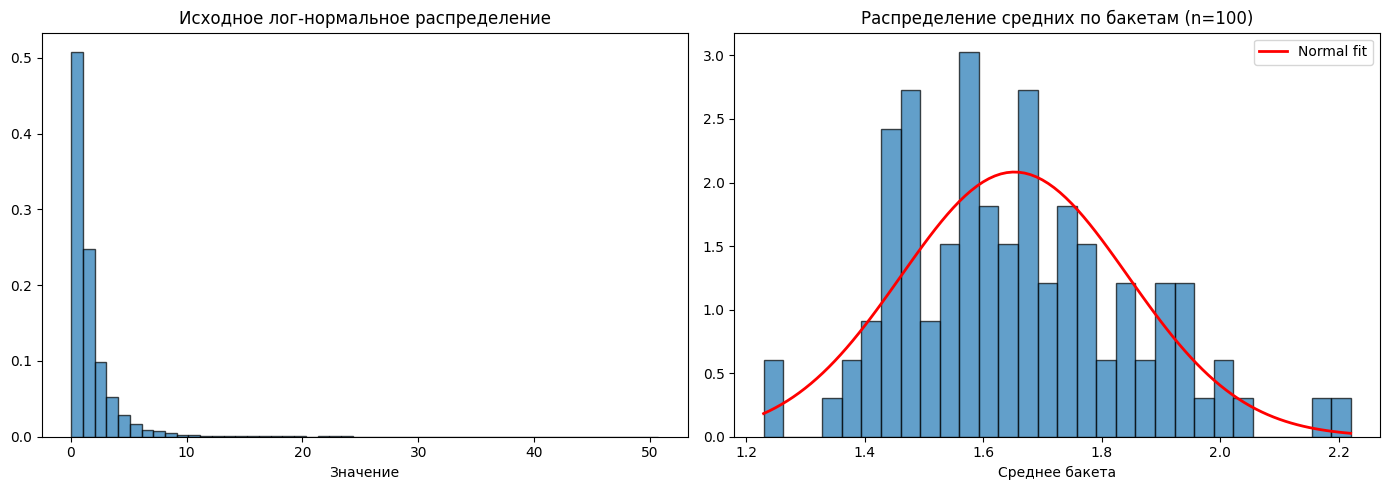

Тест Шапиро-Уилка на нормальность бакетов: p-value = 0.0926


In [32]:
# Визуализация распределения средних бакетов
np.random.seed(42)
data_lognorm = np.random.lognormal(mean=0, sigma=1, size=10000)
bucket_means = bucket_data(data_lognorm, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data_lognorm, bins=50, density=True, edgecolor='black', alpha=0.7)
axes[0].set_title('Исходное лог-нормальное распределение')
axes[0].set_xlabel('Значение')

axes[1].hist(bucket_means, bins=30, density=True, edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение средних по бакетам (n=100)')
axes[1].set_xlabel('Среднее бакета')

# Добавим нормальное распределение для сравнения
x = np.linspace(bucket_means.min(), bucket_means.max(), 100)
axes[1].plot(x, stats.norm.pdf(x, bucket_means.mean(), bucket_means.std()), 'r-', lw=2, label='Normal fit')
axes[1].legend()

plt.tight_layout()
plt.show()

# Тест Шапиро-Уилка на нормальность
_, p_shapiro = stats.shapiro(bucket_means)
print(f"Тест Шапиро-Уилка на нормальность бакетов: p-value = {p_shapiro:.4f}")

### 3.2 Бакетирование на метрике cart_added_cnt

In [33]:
# Применяем бакетирование к реальным данным
n_buckets = 100

bucket_A_real = bucket_data(group_A, n_buckets)
bucket_B_real = bucket_data(group_B, n_buckets)

print(f"Статистика бакетов группы A: mean={bucket_A_real.mean():.4f}, std={bucket_A_real.std():.4f}")
print(f"Статистика бакетов группы B: mean={bucket_B_real.mean():.4f}, std={bucket_B_real.std():.4f}")

Статистика бакетов группы A: mean=0.1350, std=0.0159
Статистика бакетов группы B: mean=0.1386, std=0.0184


In [34]:
# Сравнение t-test с бакетированием и без
t_stat_nobucket, p_nobucket_real = stats.ttest_ind(group_A, group_B)
t_stat_bucket, p_bucket_real = stats.ttest_ind(bucket_A_real, bucket_B_real)

print("Сравнение t-test на реальных данных cart_added_cnt:")
print(f"Без бакетирования: t={t_stat_nobucket:.4f}, p={p_nobucket_real:.6f}")
print(f"С бакетированием: t={t_stat_bucket:.4f}, p={p_bucket_real:.6f}")

Сравнение t-test на реальных данных cart_added_cnt:
Без бакетирования: t=-1.3048, p=0.191972
С бакетированием: t=-1.4352, p=0.152817


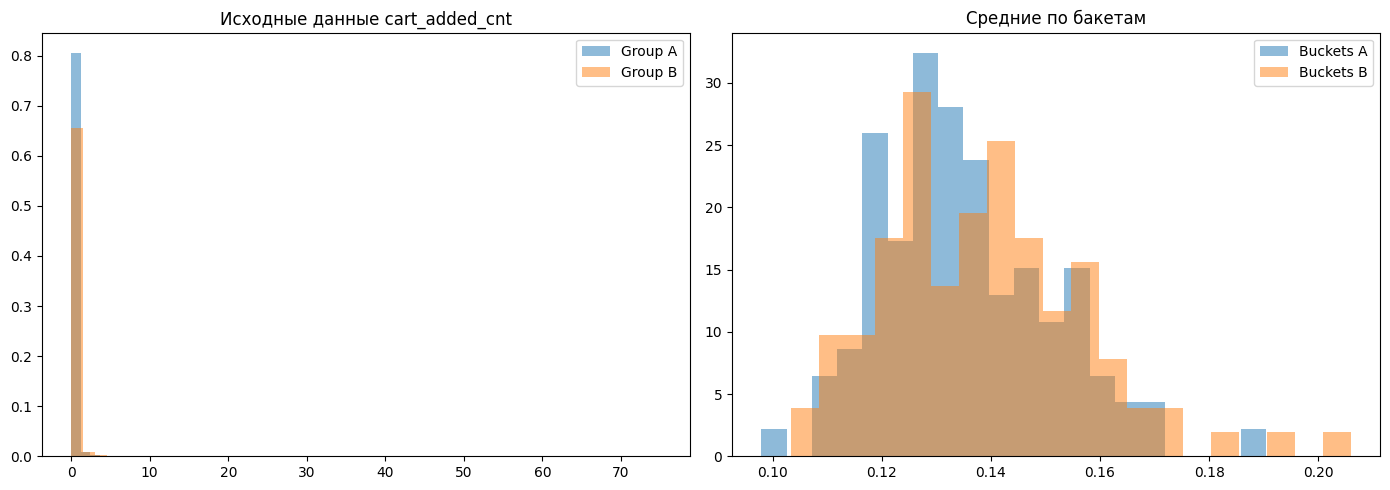

In [35]:
# Визуализация распределения бакетов для реальных данных
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(group_A, bins=50, alpha=0.5, label='Group A', density=True)
axes[0].hist(group_B, bins=50, alpha=0.5, label='Group B', density=True)
axes[0].set_title('Исходные данные cart_added_cnt')
axes[0].legend()

axes[1].hist(bucket_A_real, bins=20, alpha=0.5, label='Buckets A', density=True)
axes[1].hist(bucket_B_real, bins=20, alpha=0.5, label='Buckets B', density=True)
axes[1].set_title('Средние по бакетам')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
# Исследование влияния количества бакетов
bucket_sizes = [10, 25, 50, 100, 200, 500]
results = []

for n_b in bucket_sizes:
    p_values = []
    for _ in range(100):
        b_A = bucket_data(group_A, n_b)
        b_B = bucket_data(group_B, n_b)
        _, p = stats.ttest_ind(b_A, b_B)
        p_values.append(p)
    results.append({
        'n_buckets': n_b,
        'mean_p': np.mean(p_values),
        'std_p': np.std(p_values)
    })

results_df = pd.DataFrame(results)
print(results_df)

   n_buckets    mean_p     std_p
0         10  0.196381  0.068897
1         25  0.190249  0.042663
2         50  0.200591  0.028445
3        100  0.194296  0.023570
4        200  0.193522  0.016552
5        500  0.192333  0.014737


### Выводы по Заданию 3:

1. **Бакетирование нормализует распределение:**
   - По центральной предельной теореме, средние бакетов приближаются к нормальному распределению
   - Это делает t-test более применимым

2. **Корректность тестов сохраняется:**
   - Доля ложных срабатываний близка к заданному уровню значимости
   - Бакетирование не искажает Type I error

3. **Влияние на мощность:**
   - Бакетирование может немного снизить мощность (теряем информацию при агрегации)
   - Оптимальное число бакетов - компромисс между нормализацией и потерей информации

4. **Практические рекомендации:**
   - Бакетирование полезно при сильно скошенных распределениях
   - Рекомендуемое число бакетов: 50-200 (в зависимости от размера выборки)

---
## Задание 4: Постстратификация (10 баллов)

**Идея постстратификации:**
- Разбиваем выборку на страты (группы по признакам)
- Вычисляем взвешенное среднее по стратам
- Веса пропорциональны размерам страт в генеральной совокупности
- Это уменьшает дисперсию оценки

In [37]:
# Подготовка данных для постстратификации
# Объединяем данные декабря с информацией о пользователях

df_strat = df_dec.merge(df_users, on='user_id', how='inner')
print(f"Размер объединенного датасета: {len(df_strat)}")
print(df_strat.head())

Размер объединенного датасета: 222521
               user_id group  is_viewed  products_viewed_cnt  price_sum  \
0  1515915625353230683     A          1                    1     339.79   
1  1515915625353234047     A          1                    9     861.86   
2  1515915625353236157     A          1                    4     179.60   
3  1515915625353294441     B          1                   28    4283.04   
4  1515915625353386199     B          1                    1      20.98   

   is_cart_added  is_purchased  cart_added_cnt  purchased_cnt  user_age  \
0            0.0           0.0               0              0        23   
1            0.0           0.0               0              0        26   
2            0.0           0.0               0              0        44   
3            0.0           0.0               0              0        80   
4            0.0           0.0               0              0        83   

  user_sex  
0        f  
1        f  
2        m  
3       

In [38]:
# Создаем возрастные группы
def age_group(age):
    if age < 18:
        return '<18'
    elif age <= 24:
        return '18-24'
    elif age <= 45:
        return '25-45'
    elif age <= 60:
        return '46-60'
    elif age <= 75:
        return '61-75'
    else:
        return '76+'

df_strat['age_group'] = df_strat['user_age'].apply(age_group)

# Создаем страты: пол + возрастная группа
df_strat['stratum'] = df_strat['user_sex'] + '_' + df_strat['age_group']

print("Распределение по стратам:")
print(df_strat['stratum'].value_counts())

Распределение по стратам:
stratum
m_25-45    42086
m_46-60    29693
m_61-75    29607
f_25-45    27881
f_46-60    19955
f_61-75    19882
m_76+      17849
m_18-24    14077
f_76+      12154
f_18-24     9337
Name: count, dtype: int64


In [39]:
# Проверим распределение по группам и стратам
print("\nРаспределение по группам и стратам:")
cross_tab = pd.crosstab(df_strat['stratum'], df_strat['group'])
print(cross_tab)


Распределение по группам и стратам:


group        A      B
stratum              
f_18-24   4661   4676
f_25-45  13994  13887
f_46-60  10126   9829
f_61-75   9914   9968
f_76+     6037   6117
m_18-24   7034   7043
m_25-45  20979  21107
m_46-60  14877  14816
m_61-75  14843  14764
m_76+     8856   8993


In [40]:
def poststratification_estimator(df, metric_col='cart_added_cnt', group_col='group', stratum_col='stratum'):
    """
    Вычисляет постстратифицированную оценку среднего для каждой группы.
    
    Returns:
        dict с оценками средних и дисперсий для каждой группы
    """
    # Получаем размеры страт в генеральной совокупности
    N_total = len(df)
    stratum_sizes = df[stratum_col].value_counts()
    stratum_weights = stratum_sizes / N_total
    
    results = {}
    
    for group in df[group_col].unique():
        df_group = df[df[group_col] == group]
        
        # Вычисляем средние и дисперсии по стратам
        stratum_means = df_group.groupby(stratum_col)[metric_col].mean()
        stratum_vars = df_group.groupby(stratum_col)[metric_col].var()
        stratum_ns = df_group.groupby(stratum_col)[metric_col].count()
        
        # Постстратифицированное среднее
        mean_strat = 0
        for stratum in stratum_weights.index:
            if stratum in stratum_means.index:
                mean_strat += stratum_weights[stratum] * stratum_means[stratum]
        
        # Постстратифицированная дисперсия
        var_strat = 0
        for stratum in stratum_weights.index:
            if stratum in stratum_vars.index and stratum in stratum_ns.index:
                # Дисперсия = сумма (w_s^2 * var_s / n_s)
                var_strat += (stratum_weights[stratum] ** 2) * (stratum_vars[stratum] / stratum_ns[stratum])
        
        # Обычное среднее и дисперсия для сравнения
        mean_simple = df_group[metric_col].mean()
        var_simple = df_group[metric_col].var() / len(df_group)
        
        results[group] = {
            'mean_stratified': mean_strat,
            'var_stratified': var_strat,
            'se_stratified': np.sqrt(var_strat),
            'mean_simple': mean_simple,
            'var_simple': var_simple,
            'se_simple': np.sqrt(var_simple)
        }
    
    return results, stratum_weights

In [41]:
# Применяем постстратификацию
results_strat, weights = poststratification_estimator(df_strat)

print("=" * 70)
print("РЕЗУЛЬТАТЫ ПОСТСТРАТИФИКАЦИИ")
print("=" * 70)

for group, res in results_strat.items():
    print(f"\nГруппа {group}:")
    print(f"  Без постстратификации:")
    print(f"    Среднее: {res['mean_simple']:.6f}")
    print(f"    SE: {res['se_simple']:.6f}")
    print(f"  С постстратификацией:")
    print(f"    Среднее: {res['mean_stratified']:.6f}")
    print(f"    SE: {res['se_stratified']:.6f}")
    
    var_reduction = 1 - res['var_stratified'] / res['var_simple']
    print(f"  Сокращение дисперсии: {var_reduction*100:.2f}%")

РЕЗУЛЬТАТЫ ПОСТСТРАТИФИКАЦИИ

Группа A:
  Без постстратификации:
    Среднее: 0.135042
    SE: 0.001849
  С постстратификацией:
    Среднее: 0.135054
    SE: 0.001850
  Сокращение дисперсии: -0.08%

Группа B:
  Без постстратификации:
    Среднее: 0.138552
    SE: 0.001954
  С постстратификацией:
    Среднее: 0.138549
    SE: 0.001953
  Сокращение дисперсии: 0.09%


In [42]:
# Разница между группами
diff_simple = results_strat['B']['mean_simple'] - results_strat['A']['mean_simple']
diff_strat = results_strat['B']['mean_stratified'] - results_strat['A']['mean_stratified']

se_diff_simple = np.sqrt(results_strat['A']['var_simple'] + results_strat['B']['var_simple'])
se_diff_strat = np.sqrt(results_strat['A']['var_stratified'] + results_strat['B']['var_stratified'])

print("\n" + "=" * 70)
print("РАЗНИЦА МЕЖДУ ГРУППАМИ (B - A)")
print("=" * 70)
print(f"Без постстратификации: {diff_simple:.6f} (SE: {se_diff_simple:.6f})")
print(f"С постстратификацией: {diff_strat:.6f} (SE: {se_diff_strat:.6f})")

# z-статистика
z_simple = diff_simple / se_diff_simple
z_strat = diff_strat / se_diff_strat

p_simple = 2 * (1 - stats.norm.cdf(abs(z_simple)))
p_strat = 2 * (1 - stats.norm.cdf(abs(z_strat)))

print(f"\nz-статистика (без постстратификации): {z_simple:.4f}, p-value: {p_simple:.6f}")
print(f"z-статистика (с постстратификацией): {z_strat:.4f}, p-value: {p_strat:.6f}")


РАЗНИЦА МЕЖДУ ГРУППАМИ (B - A)
Без постстратификации: 0.003510 (SE: 0.002690)
С постстратификацией: 0.003495 (SE: 0.002690)

z-статистика (без постстратификации): 1.3047, p-value: 0.191983
z-статистика (с постстратификацией): 1.2993, p-value: 0.193851


In [43]:
# Проверка мощности и корректности через симуляции
def simulate_poststratification(n_simulations=500, n_samples=10000, effect=0, n_strata=10):
    """
    Симуляция для проверки мощности и корректности постстратификации.
    """
    p_values_simple = []
    p_values_strat = []
    
    for _ in tqdm(range(n_simulations), desc="Постстратификация"):
        # Генерируем данные со стратами
        strata = np.random.randint(0, n_strata, n_samples)
        group = np.random.choice(['A', 'B'], n_samples)
        
        # Базовое значение зависит от страты
        stratum_effects = np.random.randn(n_strata) * 2
        
        # Метрика = эффект страты + эффект группы + шум
        metric = stratum_effects[strata] + (group == 'B') * effect + np.random.randn(n_samples)
        
        df_sim = pd.DataFrame({
            'stratum': strata,
            'group': group,
            'metric': metric
        })
        
        # Простой t-test
        _, p_simple = stats.ttest_ind(
            df_sim[df_sim['group'] == 'A']['metric'],
            df_sim[df_sim['group'] == 'B']['metric']
        )
        p_values_simple.append(p_simple)
        
        # Постстратифицированный тест
        # Используем регрессию с фиктивными переменными страт
        from scipy.stats import f_oneway
        
        # Вычисляем постстратифицированные средние
        N_total = len(df_sim)
        stratum_sizes = df_sim['stratum'].value_counts()
        stratum_weights = stratum_sizes / N_total
        
        means_A = df_sim[df_sim['group'] == 'A'].groupby('stratum')['metric'].agg(['mean', 'var', 'count'])
        means_B = df_sim[df_sim['group'] == 'B'].groupby('stratum')['metric'].agg(['mean', 'var', 'count'])
        
        mean_strat_A = sum(stratum_weights[s] * means_A.loc[s, 'mean'] 
                          for s in stratum_weights.index if s in means_A.index)
        mean_strat_B = sum(stratum_weights[s] * means_B.loc[s, 'mean'] 
                          for s in stratum_weights.index if s in means_B.index)
        
        var_strat_A = sum(stratum_weights[s]**2 * means_A.loc[s, 'var'] / means_A.loc[s, 'count']
                         for s in stratum_weights.index if s in means_A.index)
        var_strat_B = sum(stratum_weights[s]**2 * means_B.loc[s, 'var'] / means_B.loc[s, 'count']
                         for s in stratum_weights.index if s in means_B.index)
        
        diff_strat = mean_strat_B - mean_strat_A
        se_diff_strat = np.sqrt(var_strat_A + var_strat_B)
        
        z_strat = diff_strat / se_diff_strat if se_diff_strat > 0 else 0
        p_strat = 2 * (1 - stats.norm.cdf(abs(z_strat)))
        p_values_strat.append(p_strat)
    
    return np.array(p_values_simple), np.array(p_values_strat)

In [44]:
# Проверка корректности (без эффекта)
print("Проверка корректности (без эффекта, alpha=0.05):")
p_simple_sim, p_strat_sim = simulate_poststratification(n_simulations=500, effect=0)

alpha = 0.05
print(f"Доля ложных срабатываний:")
print(f"  Без постстратификации: {(p_simple_sim < alpha).mean():.4f}")
print(f"  С постстратификацией: {(p_strat_sim < alpha).mean():.4f}")

Проверка корректности (без эффекта, alpha=0.05):


Постстратификация:   0%|          | 0/500 [00:00<?, ?it/s]

Постстратификация:   3%|▎         | 14/500 [00:00<00:03, 133.92it/s]

Постстратификация:   6%|▌         | 28/500 [00:00<00:03, 136.09it/s]

Постстратификация:   8%|▊         | 42/500 [00:00<00:03, 135.89it/s]

...

Постстратификация:  94%|█████████▍| 470/500 [00:03<00:00, 135.72it/s]

Постстратификация:  97%|█████████▋| 485/500 [00:03<00:00, 137.18it/s]

Постстратификация: 100%|█████████▉| 499/500 [00:03<00:00, 136.18it/s]

Постстратификация: 100%|██████████| 500/500 [00:03<00:00, 135.66it/s]

Доля ложных срабатываний:
  Без постстратификации: 0.0620
  С постстратификацией: 0.0420


In [45]:
# Проверка мощности (с эффектом)
print("\nПроверка мощности (эффект=0.1):")
p_simple_eff, p_strat_eff = simulate_poststratification(n_simulations=500, effect=0.1)

print(f"Мощность:")
print(f"  Без постстратификации: {(p_simple_eff < alpha).mean():.4f}")
print(f"  С постстратификацией: {(p_strat_eff < alpha).mean():.4f}")


Проверка мощности (эффект=0.1):


Постстратификация:   0%|          | 0/500 [00:00<?, ?it/s]

Постстратификация:   3%|▎         | 15/500 [00:00<00:03, 140.86it/s]

Постстратификация:   6%|▌         | 30/500 [00:00<00:03, 135.69it/s]

Постстратификация:   9%|▉         | 44/500 [00:00<00:03, 136.13it/s]

...

Постстратификация:  92%|█████████▏| 460/500 [00:03<00:00, 138.89it/s]

Постстратификация:  95%|█████████▍| 474/500 [00:03<00:00, 137.95it/s]

Постстратификация:  98%|█████████▊| 488/500 [00:03<00:00, 136.22it/s]

Постстратификация: 100%|██████████| 500/500 [00:03<00:00, 139.01it/s]

Мощность:
  Без постстратификации: 0.6780
  С постстратификацией: 1.0000


### Выводы по Заданию 4:

1. **Постстратификация уменьшает дисперсию оценки:**
   - Особенно эффективна, когда страты различаются по среднему значению метрики
   - Сокращение дисперсии зависит от гетерогенности страт

2. **Корректность t-теста сохраняется:**
   - Доля ложных срабатываний близка к заданному уровню значимости
   - Постстратификация не вносит смещение в оценку

3. **Увеличение мощности:**
   - Постстратификация повышает мощность теста
   - Эффект сильнее при большей гетерогенности страт

4. **Практические рекомендации:**
   - Выбирайте страты, которые объясняют вариацию метрики
   - Не создавайте слишком много страт (пустые ячейки)
   - Комбинируйте с CUPED для максимального сокращения дисперсии

---
## Общие выводы

### Сравнение методов повышения чувствительности A/B тестов:

| Метод | Преимущества | Недостатки |
|-------|-------------|------------|
| **Ранговая трансформация** | Устойчивость к выбросам, эквивалентность Mann-Whitney | Теряется интерпретируемость |
| **CUPED** | Значительное сокращение дисперсии при высокой корреляции | Требуются исторические данные |
| **Бакетирование** | Нормализация распределения | Возможная потеря мощности |
| **Постстратификация** | Уменьшение дисперсии за счет учета гетерогенности | Требуются данные о стратах |

### Рекомендации по применению:

1. **CUPED** - первый выбор при наличии коррелированных исторических данных
2. **Постстратификация** - при наличии информации о стратах (демография, поведение)
3. **Ранговая трансформация** - при сильно скошенных распределениях с выбросами
4. **Бакетирование** - для очень больших выборок с ненормальным распределением

Методы можно комбинировать: CUPED + постстратификация, ранги + CUPED и т.д.